In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. Load Pathway Results
# Replace with your actual file path
df = pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Results/csvs/GeoMx_DGE_LMM_Satterthwaite_Results_Raw_Pathways.csv")

# Clean and rename
df['Estimate'] = pd.to_numeric(df['Estimate'], errors='coerce')
df['P_Value'] = pd.to_numeric(df['P_Value'], errors='coerce')
df = df.rename(columns={'Gene': 'Pathway'}) if 'Gene' in df.columns else df
df['-log10P'] = -np.log10(df['P_Value'])

# 2. Define Thresholds
p_thresh = 0.01
fc_thresh = 0.02

# Data subsets
sig_up = df[(df['P_Value'] < p_thresh) & (df['Estimate'] > fc_thresh)]
sig_down = df[(df['P_Value'] < p_thresh) & (df['Estimate'] < -fc_thresh)]
non_sig = df[~df.index.isin(sig_up.index) & ~df.index.isin(sig_down.index)]

# Top 15 for labeling (Top Up and Top Down)
top_up = sig_up.sort_values('Estimate', ascending=False).head(15)
top_down = sig_down.sort_values('Estimate', ascending=True).head(15)
top_pathways = pd.concat([top_up, top_down])



In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. Load Pathway Results
# Ensure the path points to your actual LMM results file
try:
    df = pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Results/csvs/GeoMx_DGE_LMM_Satterthwaite_Results_Raw_Pathways.csv")
except FileNotFoundError:
    print("File not found. Please check the file path.")
    # Creating a dummy df for structural demonstration if file is missing
    df = pd.DataFrame(columns=['Gene', 'Estimate', 'P_Value'])

# 2. Clean and Prepare Data
df['Estimate'] = pd.to_numeric(df['Estimate'], errors='coerce')
df['P_Value'] = pd.to_numeric(df['P_Value'], errors='coerce')
df = df.dropna(subset=['Estimate', 'P_Value'])

# Rename column if necessary
if 'Gene' in df.columns:
    df = df.rename(columns={'Gene': 'Pathway'})

# Calculate -log10(P-value)
df['-log10P'] = -np.log10(df['P_Value'])

# 3. Define Thresholds
p_thresh = 0.01
fc_thresh = 0.02

# Categorize data subsets
sig_up = df[(df['P_Value'] < p_thresh) & (df['Estimate'] > fc_thresh)]
sig_down = df[(df['P_Value'] < p_thresh) & (df['Estimate'] < -fc_thresh)]
non_sig = df[~df.index.isin(sig_up.index) & ~df.index.isin(sig_down.index)]

# Select top 15 Up and 15 Down for labeling
top_up = sig_up.sort_values('Estimate', ascending=False).head(15)
top_down = sig_down.sort_values('Estimate', ascending=True).head(15)
top_pathways = pd.concat([top_up, top_down])

# 4. Build the Interactive Plot
fig = go.Figure()

# Trace: Non-Significant (Grey)
fig.add_trace(go.Scatter(
    x=non_sig['Estimate'], 
    y=non_sig['-log10P'],
    mode='markers', 
    name='Non-Significant',
    text=non_sig['Pathway'], 
    hoverinfo='text',
    marker={'color': 'grey', 'opacity': 0.2, 'size': 6}
))

# Trace: Significant Up (Red)
fig.add_trace(go.Scatter(
    x=sig_up['Estimate'], 
    y=sig_up['-log10P'],
    mode='markers', 
    name='Significant Up',
    text=sig_up['Pathway'], 
    hoverinfo='text',
    marker={'color': 'firebrick', 'opacity': 0.8, 'size': 9, 'line': {'width': 0.5, 'color': 'black'}}
))

# Trace: Significant Down (Blue)
fig.add_trace(go.Scatter(
    x=sig_down['Estimate'], 
    y=sig_down['-log10P'],
    mode='markers', 
    name='Significant Down',
    text=sig_down['Pathway'], 
    hoverinfo='text',
    marker={'color': 'royalblue', 'opacity': 0.8, 'size': 9, 'line': {'width': 0.5, 'color': 'black'}}
))

# 5. Add Annotations for Top Pathways
for i, row in top_pathways.iterrows():
    fig.add_annotation(
        x=row['Estimate'], 
        y=row['-log10P'],
        text=row['Pathway'].replace('_', ' '), # Clean underscores for display
        showarrow=True, 
        arrowhead=1, 
        arrowcolor='darkgrey',
        arrowsize=1,
        arrowwidth=0.8,
        ax=50 if row['Estimate'] > 0 else -50, # Label offset
        ay=-40,
        font=dict(size=9, color="black"),
        xanchor="left" if row['Estimate'] > 0 else "right"
    )

# 6. Layout and Threshold Lines
fig.update_layout(
    title={
        'text': "<b>Pathway Enrichment: High vs Low Proliferation Niche</b><br><sup>Thresholds: |Estimate| > 0.02 & P < 0.01</sup>",
        'x': 0.05,
        'xanchor': 'left'
    },
    xaxis_title="<b>Differential Enrichment Score (Estimate)</b>",
    yaxis_title="<b>-log10(P-Value)</b>",
    template="simple_white",
    width=1100,
    height=800,
    hovermode="closest",
    shapes=[
        # Vertical threshold lines
        dict(type="line", x0=-fc_thresh, x1=-fc_thresh, y0=0, y1=df['-log10P'].max(), 
             line=dict(color="black", dash="dot", width=1)),
        dict(type="line", x0=fc_thresh, x1=fc_thresh, y0=0, y1=df['-log10P'].max(), 
             line=dict(color="black", dash="dot", width=1)),
        # Horizontal threshold line
        dict(type="line", x0=df['Estimate'].min(), x1=df['Estimate'].max(), 
             y0=-np.log10(p_thresh), y1=-np.log10(p_thresh), 
             line=dict(color="black", dash="dot", width=1))
    ]
)

import plotly.io as pio
pio.renderers.default = "browser" # This will open the plot in a new Chrome/Safari tab
fig.show()
# 7. Show and Save


# Optional: Save a static version (requires kaleido)
# fig.write_image("HGSC_Volcano_Plot.png", scale=3)

# Save significant results to CSV
sig_final = pd.concat([sig_up, sig_down]).sort_values('P_Value')
sig_final.to_csv("Significant_Pathways_Summary.csv", index=False)

## Volcano AND OTHER plots , significant ssgsea pathways with p=0.01 and fc_thresh=0.02

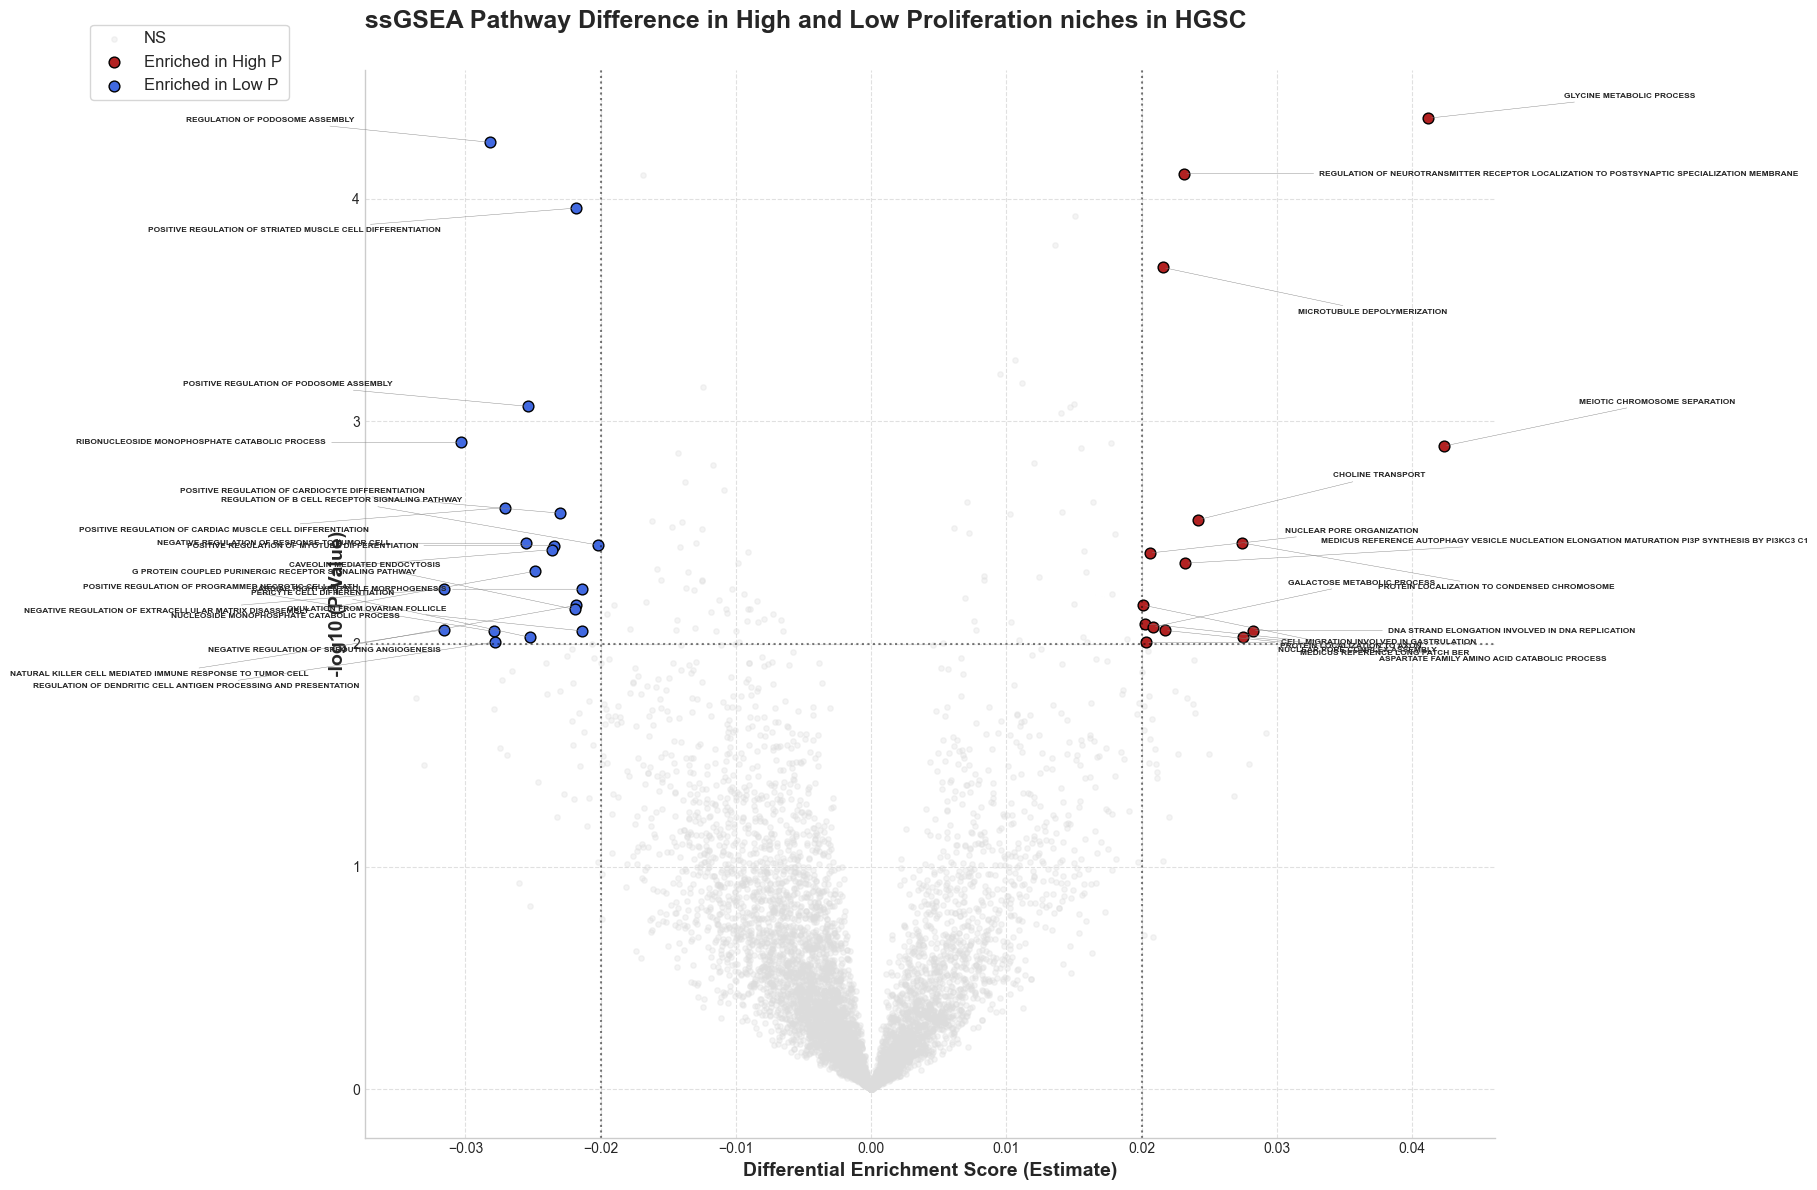

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_thesis_volcano_final(df, title="ssGSEA Pathway Difference in High and Low Proliferation niches in HGSC"):
    df = df.copy()
    
    # 1. Clean Names: ALL CAPS and remove prefixes
    df['Pathway'] = df['Pathway'].str.replace(r'^(GOBP_|KEGG_|REACTOME_)', '', regex=True)
    df['Pathway'] = df['Pathway'].str.replace('_', ' ').str.upper()
    
    # 2. Define Significance
    p_thresh = 0.01
    fc_thresh = 0.02
    df['-log10P'] = -np.log10(df['P_Value'])
    
    # 3. Figure Setup: Tall and Wide to accommodate ALL labels
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 12)) 
    
    # Subsets for plotting
    up = df[(df['P_Value'] < p_thresh) & (df['Estimate'] > fc_thresh)]
    down = df[(df['P_Value'] < p_thresh) & (df['Estimate'] < -fc_thresh)]
    non_sig = df[~df.index.isin(up.index) & ~df.index.isin(down.index)]

    # 4. Scatter Plot
    ax.scatter(non_sig['Estimate'], non_sig['-log10P'], c='gainsboro', alpha=0.3, s=15, label='NS')
    ax.scatter(up['Estimate'], up['-log10P'], c='firebrick', s=60, edgecolors='black', label='Enriched in High P')
    ax.scatter(down['Estimate'], down['-log10P'], c='royalblue', s=60, edgecolors='black', label='Enriched in Low P')

    # 5. Threshold Lines
    ax.axhline(-np.log10(p_thresh), color='black', linestyle=':', alpha=0.5)
    ax.axvline(fc_thresh, color='black', linestyle=':', alpha=0.5)
    ax.axvline(-fc_thresh, color='black', linestyle=':', alpha=0.5)
    
    # 6. Label ALL Significant Pathways
    all_sig = pd.concat([up, down]).sort_values('Estimate')
    
    # We use a very small font (6pt) and short arrows as requested
    for i, (idx, row) in enumerate(all_sig.iterrows()):
        # Determine side for label placement
        is_right = row['Estimate'] > 0
        x_offset = 0.01 if is_right else -0.01
        
        # Stagger labels vertically to prevent overlap in dense areas
        # Multiplier creates more spread the further they are from the center
        y_offset = (i % 5 - 2) * 0.1 
        
        ax.annotate(row['Pathway'], 
                    xy=(row['Estimate'], row['-log10P']),
                    xytext=(row['Estimate'] + x_offset, row['-log10P'] + y_offset),
                    fontsize=6, # Smaller font
                    fontweight='bold',
                    ha='left' if is_right else 'right',
                    va='center',
                    arrowprops=dict(arrowstyle='-', color='grey', lw=0.3)) # Shorter/Thinner arrows

    # 7. Final Formatting
    ax.set_title(title, loc='left', fontweight='bold', fontsize=18, pad=30)
    ax.set_xlabel('Differential Enrichment Score (Estimate)', fontweight='bold', fontsize=14)
    ax.set_ylabel('-log10 (P-Value)', fontweight='bold', fontsize=14)
    ax.legend(frameon=True, loc='upper left', fontsize=12, bbox_to_anchor=(-0.25, 1.05))
    
    # Standardize grid to match GSEA plot
    ax.grid(True, linestyle='--', alpha=0.6)
    
    sns.despine()
    plt.tight_layout()
    
    # Save significant results to CSV as requested
    all_sig.to_csv("Significant_Pathways_All_Labeled.csv", index=False)
    
    return fig

# Execute
fig_volcano = plot_thesis_volcano_final(df)
plt.show()

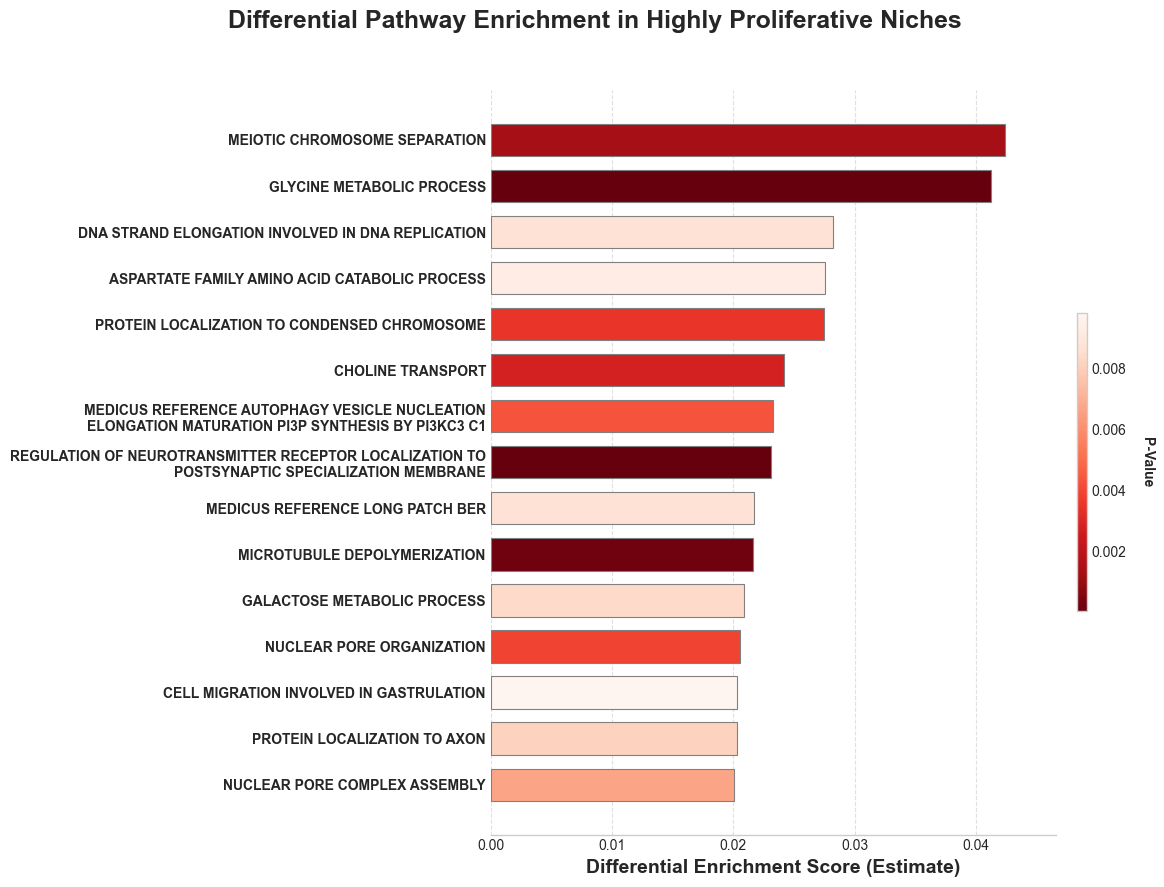

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import textwrap # <-- Imported for text wrapping

def plot_thesis_barchart_balanced(df, title="Differential Pathway Enrichment in Highly Proliferative Niches"):
    df = df.copy()
    
    # 1. Clean Names: remove prefixes, clean up underscores, and make ALL CAPS
    df['Pathway'] = df['Pathway'].str.replace(r'^(GOBP_|KEGG_|REACTOME_)', '', regex=True)
    df['Pathway'] = df['Pathway'].str.replace('_', ' ').str.upper() 
    
    # Wrap long labels at 55 characters so they don't squish the plot area
    df['Pathway'] = df['Pathway'].apply(lambda x: textwrap.fill(x, width=55))
    
    # 2. Define Significance Limits
    p_thresh = 0.01
    fc_thresh = 0.02
    
    # 3. Filter for ONLY Upregulated in High P
    up = df[(df['P_Value'] < p_thresh) & (df['Estimate'] > fc_thresh)].copy()
    
    # Sort by Estimate
    up = up.sort_values(by='Estimate', ascending=True)

    # 4. Figure Setup
    fig_height = max(8, len(up) * 0.6) 
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, fig_height)) 
    
    # 5. Color Mapping: P-Value 
    cmap = plt.cm.Reds_r
    norm = mcolors.Normalize(vmin=up['P_Value'].min(), vmax=up['P_Value'].max())
    colors = cmap(norm(up['P_Value']))

    # 6. Plot Horizontal Bars
    bars = ax.barh(up['Pathway'], up['Estimate'], color=colors, edgecolor='grey', linewidth=0.8, height=0.7)

    # 7. Final Formatting
    fig.suptitle(title, fontweight='bold', fontsize=18, y=0.98) 
    ax.set_xlabel('Differential Enrichment Score (Estimate)', fontweight='bold', fontsize=14)
    
    # ---> NEW: Make the pathway names on the y-axis bold <---
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    
    # Give the right side of the chart 10% more padding so the longest bar doesn't hit the colorbar
    ax.set_xlim(0, up['Estimate'].max() * 1.1)
    
    # Clean up the grid
    ax.grid(True, axis='x', linestyle='--', alpha=0.6)
    ax.grid(False, axis='y') 
    sns.despine(left=True, bottom=False) 
    
    # 8. Add Colorbar Legend
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, aspect=30, shrink=0.4, pad=0.03)
    cbar.set_label('P-Value', fontweight='bold', rotation=270, labelpad=20)
    
    # tight_layout with a rect ensures the suptitle isn't cut off
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save the filtered results to a new CSV
    up.sort_values(by='Estimate', ascending=False).to_csv("Upregulated_High_Proliferation_Pathways.csv", index=False)
    
    return fig

# Execute (Make sure your 'df' is loaded before running this)
fig_barchart = plot_thesis_barchart_balanced(df)
plt.show()

## Volcano plots , significant ssgsea pathways with p=0.005 and fc_thresh=0.021

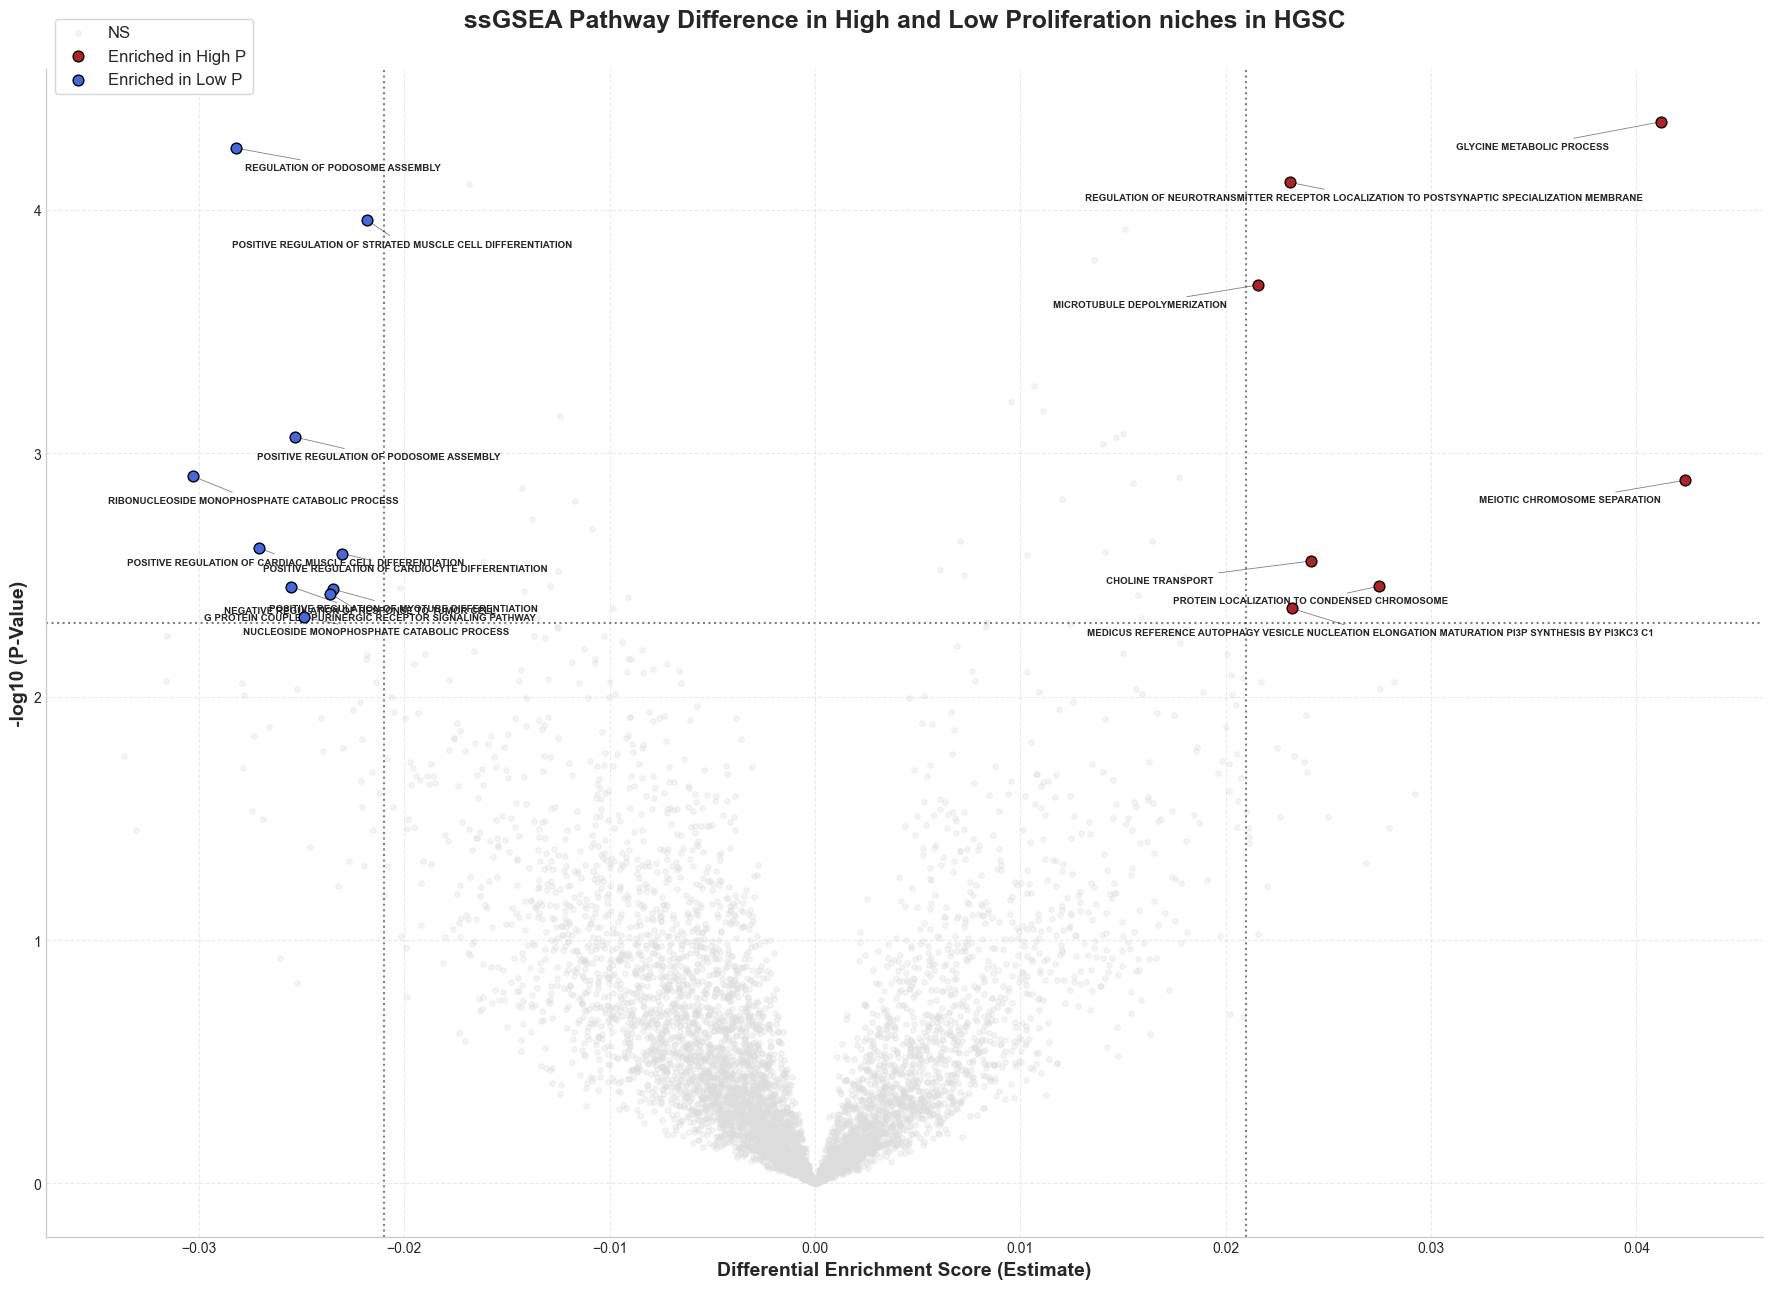

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_thesis_volcano_final(df, title="ssGSEA Pathway Difference in High and Low Proliferation niches in HGSC"):
    df = df.copy()
    
    # 1. Clean Names
    df['Pathway'] = df['Pathway'].str.replace(r'^(GOBP_|KEGG_|REACTOME_)', '', regex=True)
    df['Pathway'] = df['Pathway'].str.replace('_', ' ').str.upper()
    
    # 2. Define Significance
    p_thresh = 0.005
    fc_thresh = 0.021
    df['-log10P'] = -np.log10(df['P_Value'])
    
    # 3. Figure Setup
    plt.style.use('seaborn-v0_8-whitegrid')
    # Increased height slightly to accommodate the vertical staggering of ALL labels
    fig, ax = plt.subplots(figsize=(18, 13)) 
    
    up = df[(df['P_Value'] < p_thresh) & (df['Estimate'] > fc_thresh)]
    down = df[(df['P_Value'] < p_thresh) & (df['Estimate'] < -fc_thresh)]
    non_sig = df[~df.index.isin(up.index) & ~df.index.isin(down.index)]

    # 4. Scatter Plot
    ax.scatter(non_sig['Estimate'], non_sig['-log10P'], c='gainsboro', alpha=0.3, s=15, label='NS')
    ax.scatter(up['Estimate'], up['-log10P'], c='firebrick', s=60, edgecolors='black', label='Enriched in High P', zorder=5)
    ax.scatter(down['Estimate'], down['-log10P'], c='royalblue', s=60, edgecolors='black', label='Enriched in Low P', zorder=5)

    # 5. Threshold Lines
    ax.axhline(-np.log10(p_thresh), color='black', linestyle=':', alpha=0.5)
    ax.axvline(fc_thresh, color='black', linestyle=':', alpha=0.5)
    ax.axvline(-fc_thresh, color='black', linestyle=':', alpha=0.5)
    
    # 6. Label ALL Significant Pathways with ULTRA-SHORT arrows
    all_sig = pd.concat([up, down]).sort_values('Estimate')
    
    for i, (idx, row) in enumerate(all_sig.iterrows()):
        is_right = row['Estimate'] > 0
        
        # Reduced x_offset to bring text closer to dots
        x_offset = -0.01 if is_right else 0.01
        
        # Reduced y_offset for tighter staggering
        # This creates a small vertical "fan" so labels don't overlap
        y_offset = (i % 3 - 5) * 0.02
        
        ax.annotate(row['Pathway'], 
                    xy=(row['Estimate'], row['-log10P']),
                    xytext=(row['Estimate'] + x_offset, row['-log10P'] + y_offset),
                    fontsize=7, # Slightly smaller for extreme density
                    fontweight='bold',
                    ha='left' if is_right else 'right',
                    va='center',
                    # 'coord' connection style makes the line as short and direct as possible
                    arrowprops=dict(arrowstyle='-', 
                                    color='black', 
                                    lw=0.6, 
                                    alpha=0.5,
                                    connectionstyle="arc3,rad=0"))

    # 7. Final Formatting
    ax.set_title(title, loc='center', fontweight='bold', fontsize=18, pad=30)
    ax.set_xlabel('Differential Enrichment Score (Estimate)', fontweight='bold', fontsize=14)
    ax.set_ylabel('-log10 (P-Value)', fontweight='bold', fontsize=14)
    
    # Adjusted legend to be inside the plot margin or just outside
    ax.legend(frameon=True, loc='upper left', fontsize=12, bbox_to_anchor=(-0.0, 1.05))
    
    ax.grid(True, linestyle='--', alpha=0.4)
    
    sns.despine()
    plt.tight_layout()
    
    all_sig.to_csv("Significant_Pathways_All_Labeled.csv", index=False)
    
    return fig

# Execute
fig_volcano = plot_thesis_volcano_final(df)
plt.show()

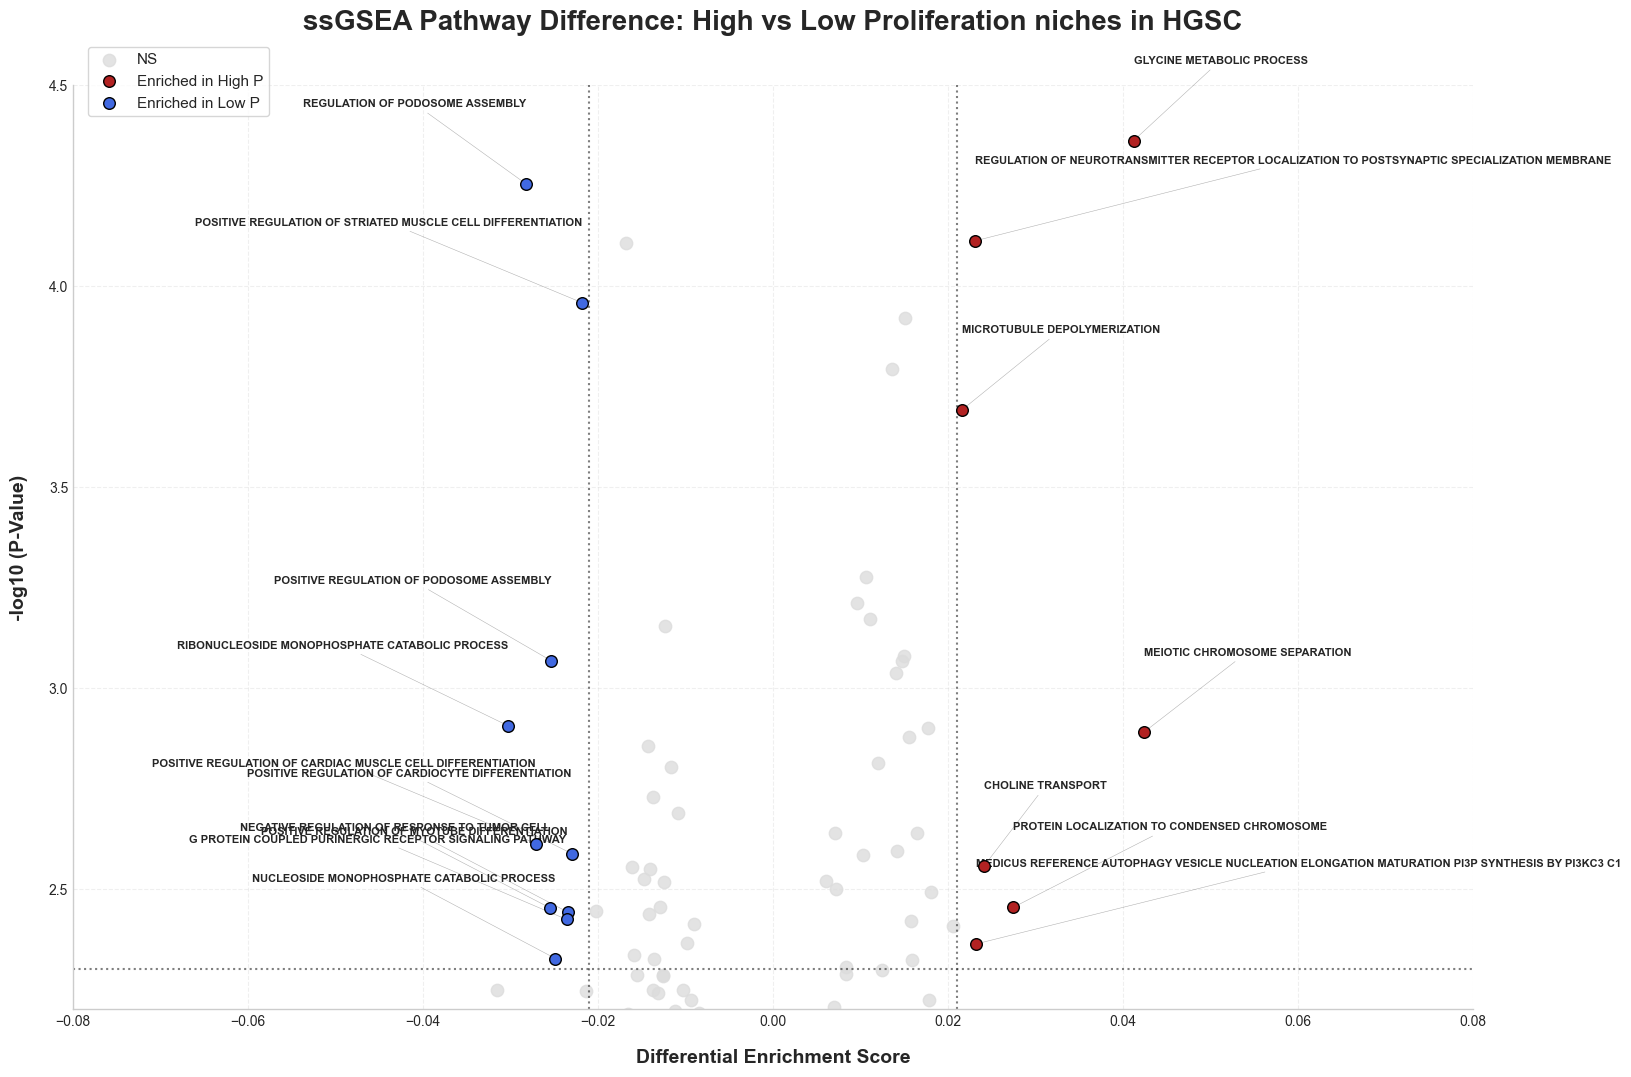

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_thesis_volcano_final(df, title="ssGSEA Pathway Difference: High vs Low Proliferation niches in HGSC"):
    df = df.copy()
    
    # 1. Clean Names
    df['Pathway'] = df['Pathway'].str.replace(r'^(GOBP_|KEGG_|REACTOME_)', '', regex=True)
    df['Pathway'] = df['Pathway'].str.replace('_', ' ').str.upper()
    
    # 2. Define Significance
    p_thresh = 0.005
    fc_thresh = 0.021
    df['-log10P'] = -np.log10(df['P_Value'])
    
    # 3. Figure Setup
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(20, 12)) # Slightly wider figure
    
    up = df[(df['P_Value'] < p_thresh) & (df['Estimate'] > fc_thresh)]
    down = df[(df['P_Value'] < p_thresh) & (df['Estimate'] < -fc_thresh)]
    non_sig = df[~df.index.isin(up.index) & ~df.index.isin(down.index)]

    # 4. Scatter Plot
    ax.scatter(non_sig['Estimate'], non_sig['-log10P'], c='gainsboro', alpha=0.8, s=80, label='NS')
    ax.scatter(up['Estimate'], up['-log10P'], c='firebrick', s=70, edgecolors='black', label='Enriched in High P', zorder=5)
    ax.scatter(down['Estimate'], down['-log10P'], c='royalblue', s=70, edgecolors='black', label='Enriched in Low P', zorder=5)

    # 5. Threshold Lines
    ax.axhline(-np.log10(p_thresh), color='black', linestyle=':', alpha=0.5)
    ax.axvline(fc_thresh, color='black', linestyle=':', alpha=0.5)
    ax.axvline(-fc_thresh, color='black', linestyle=':', alpha=0.5)
    
    # 6. Label ALL Significant Pathways
    all_sig = pd.concat([up, down]).sort_values('-log10P', ascending=False)
    
    for i, (idx, row) in enumerate(all_sig.iterrows()):
        is_right = row['Estimate'] > 0
        
        # Micro-offsets for short arrows
        x_offset = -0. if is_right else 0.00
        #y_offset = (i % 35-15) * 0.1
        y_offset =  0.2


        ax.annotate(row['Pathway'], 
                    xy=(row['Estimate'], row['-log10P']),
                    xytext=(row['Estimate'] + x_offset, row['-log10P'] + y_offset),
                    fontsize=8, 
                    fontweight='bold',
                    ha='left' if is_right else 'right',
                    va='center',
                    arrowprops=dict(arrowstyle='-', color='black', lw=0.4, alpha=0.3))

    # 7. Formatting & X-AXIS EXTENSION
    # This provides the empty space on the sides for the long pathway names
    ax.set_xlim(-0.08, 0.08) 
    ax.set_ylim(2.2, 4.5) 
    
    ax.set_title(title, loc='center', fontweight='bold', fontsize=20, pad=40)
    ax.set_xlabel('Differential Enrichment Score', fontweight='bold', fontsize=14, labelpad=15)
    ax.set_ylabel('-log10 (P-Value)', fontweight='bold', fontsize=14, labelpad=15)
    
    # Legend - moved to be clearly visible
    ax.legend(frameon=True, loc='upper left', fontsize=11, bbox_to_anchor=(0.005, 1.05))
    
    ax.grid(True, linestyle='--', alpha=0.3)
    sns.despine()
    
    # Use subplots_adjust to ensure the y-axis label isn't clipped
    plt.subplots_adjust(left=0.15, right=0.85)
    
    return fig

# Execute
fig_volcano = plot_thesis_volcano_final(df)
plt.show()

## Volcano Plot for Differentially Expressed Genes (log2FC =0.3, p-value=0.001)


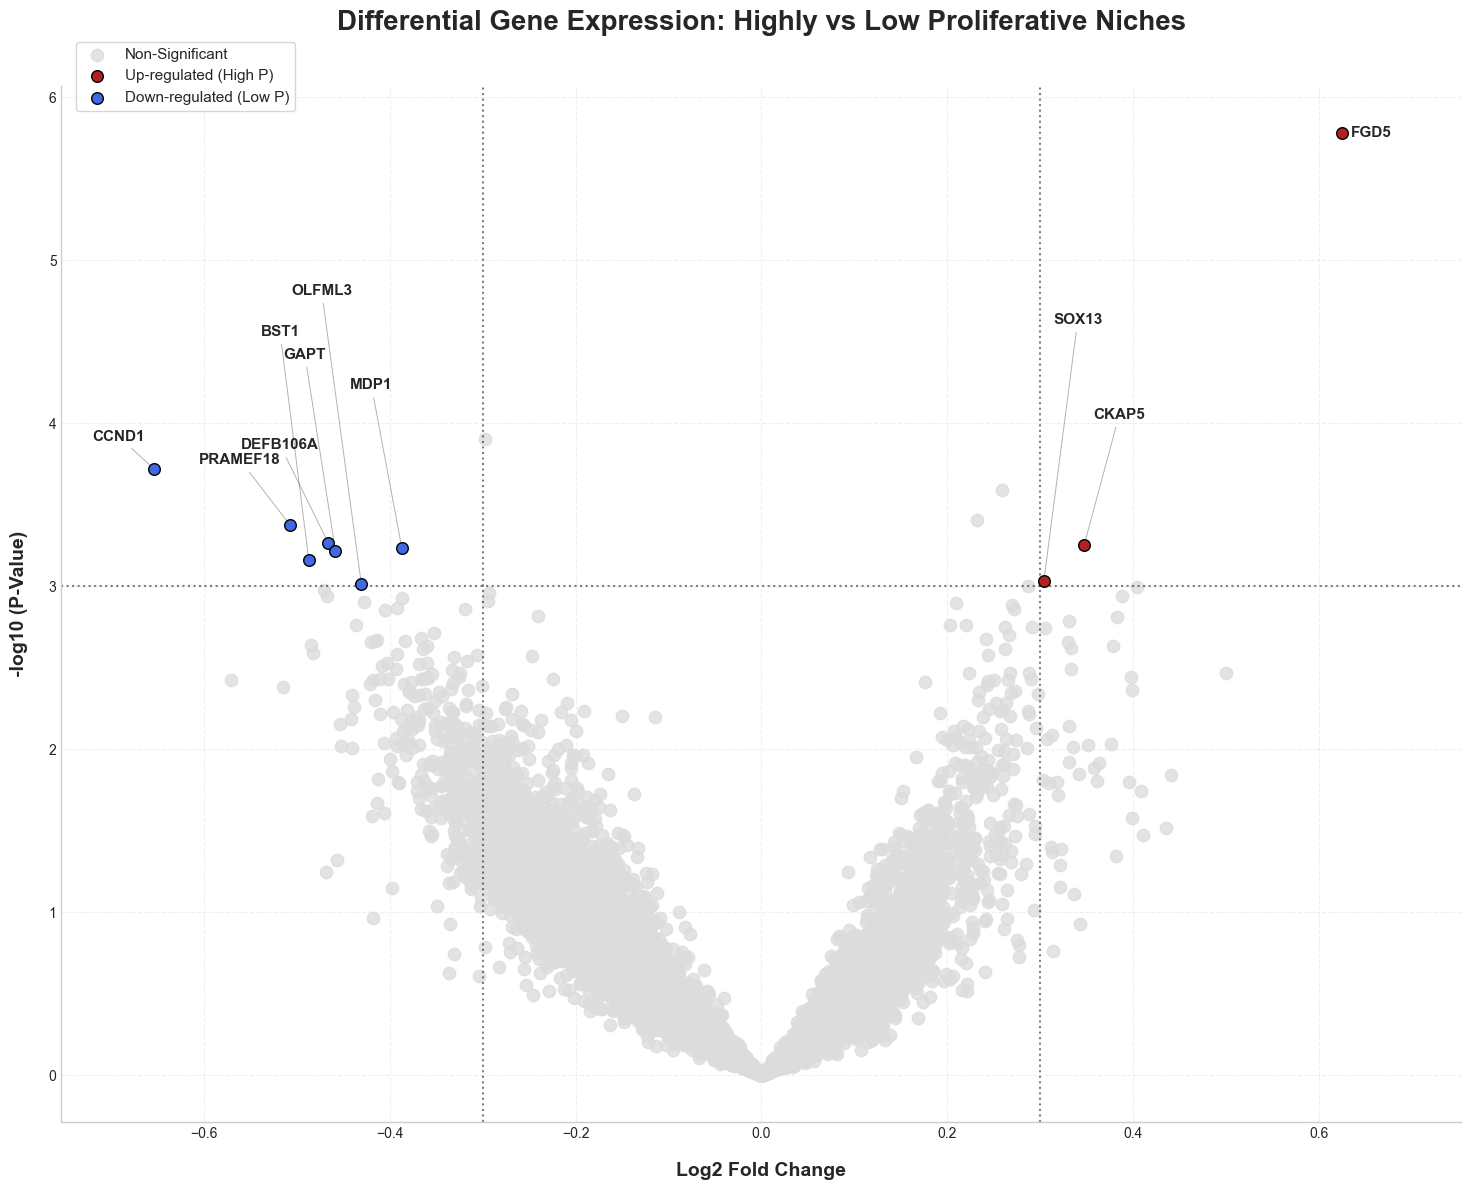

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
file_path = '/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Results/csvs/GeoMx_DGE_LMM_Satterthwaite_Results_Bulk.csv'

# We load without index_col=0 to keep 'Gene' as a column. 
# If the CSV has no header for genes, we rename it.
dge_limma_genes = pd.read_csv(file_path)

# If the first column is unnamed or named 'Unnamed: 0', rename it to 'Gene'
if 'Gene' not in dge_limma_genes.columns:
    dge_limma_genes.rename(columns={dge_limma_genes.columns[0]: 'Gene'}, inplace=True)

def plot_gene_volcano(df, title="Differential Gene Expression: Highly vs Low Proliferative Niches"):
    df = df.copy()
    
    # Ensure numeric types for calculation
    df['Estimate'] = pd.to_numeric(df['Estimate'], errors='coerce')
    df['P_Value'] = pd.to_numeric(df['P_Value'], errors='coerce')
    df = df.dropna(subset=['Estimate', 'P_Value']) # Remove rows with missing stats
    
    df['-log10P'] = -np.log10(df['P_Value'])
    
    # 2. Significance Thresholds (Gene-level)
    p_thresh = 0.001
    fc_thresh = 0.3
    
    # 3. Figure Setup
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(20, 12)) 
    
    up = df[(df['P_Value'] < p_thresh) & (df['Estimate'] > fc_thresh)]
    down = df[(df['P_Value'] < p_thresh) & (df['Estimate'] < -fc_thresh)]
    non_sig = df[~df.index.isin(up.index) & ~df.index.isin(down.index)]

    # 4. Scatter Plot
    ax.scatter(non_sig['Estimate'], non_sig['-log10P'], c='gainsboro', alpha=0.8, s=80, label='Non-Significant')
    ax.scatter(up['Estimate'], up['-log10P'], c='firebrick', s=70, edgecolors='black', label='Up-regulated (High P)', zorder=5)
    ax.scatter(down['Estimate'], down['-log10P'], c='royalblue', s=70, edgecolors='black', label='Down-regulated (Low P)', zorder=5)

    # 5. Threshold Lines
    ax.axhline(-np.log10(p_thresh), color='black', linestyle=':', alpha=0.5)
    ax.axvline(fc_thresh, color='black', linestyle=':', alpha=0.5)
    ax.axvline(-fc_thresh, color='black', linestyle=':', alpha=0.5)
    
    # 6. Label ALL Significant Genes
    all_sig = pd.concat([up, down]).sort_values('-log10P', ascending=False)
    
    for i, (idx, row) in enumerate(all_sig.iterrows()):
        is_right = row['Estimate'] > 0
        
        # Adjust x_offset to push text outward
        x_offset = 0.01 if is_right else -0.01
        # Modulo 15 to prevent stacking in dense vertical areas
        y_offset = (i % 35  ) * 0.2
        
        ax.annotate(row['Gene'], 
                    xy=(row['Estimate'], row['-log10P']),
                    xytext=(row['Estimate'] + x_offset, row['-log10P'] + y_offset),
                    fontsize=11, 
                    fontweight='bold',
                    ha='left' if is_right else 'right',
                    va='center',
                    arrowprops=dict(arrowstyle='-', 
                                    color='black', 
                                    lw=0.7, 
                                    alpha=0.3,
                                    connectionstyle="arc3,rad=0"))

    # 7. Final Formatting & Scaling
    max_range = max(abs(df['Estimate'].min()), abs(df['Estimate'].max()))
    ax.set_xlim(-max_range - 0.1, max_range + 0.1)
    
    ax.set_title(title, loc='center', fontweight='bold', fontsize=20, pad=40)
    ax.set_xlabel('Log2 Fold Change', fontweight='bold', fontsize=14, labelpad=15)
    ax.set_ylabel('-log10 (P-Value)', fontweight='bold', fontsize=14, labelpad=15)
    
    ax.legend(frameon=True, loc='upper left', fontsize=11, bbox_to_anchor=(0.005, 1.05))
    
    ax.grid(True, linestyle='--', alpha=0.3)
    sns.despine()
    plt.tight_layout()
    plt.subplots_adjust(left=0.15, right=0.85)
    
    return fig

# --- EXECUTION ---
fig_genes = plot_gene_volcano(dge_limma_genes)
plt.show()